In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as inter
from scipy import odr as mmq
import pandas as pd

# Simulação do Tubo de Raios Catódicos (TRC)

## Objetivo
Simular a trajetória do elétron sob campo elétrico obtido via FEMM e comparar com dados experimentais.

## Estrutura do notebook

1. Definição dos parâmetros
2. Importação do campo elétrico
3. Aproximação do modelo físico
4. Construção da função de campo
5. Validação do campo
6. Simulação da trajetória
7. Ajuste aos dados experimentais
8. Trajetória $(x,y)$ do elétron e impacto na tela

## Metodologia
- Campo elétrico obtido por simulação numérica
- Integração da equação de movimento

## Configurações do Notebook

In [ ]:
# =============================================================================
# 1. ARQUIVOS DE DADOS
# =============================================================================
# Experimento 1: Dados de Vp variável e Vac fixo
arquivo_vac_fixo = 'teste femm/dados_experimentais_VacFixo.csv'

# Experimento 2: Dados de Vac variável e Vp fixo
arquivo_tela = 'teste femm/dados_tela.csv'

# Caminho para os dados do campo elétrico (FEMM)
arquivo_campo_eletrico = 'teste femm/electric_field_data.csv'

# =============================================================================
# 2. PARÂMETROS DA SIMULAÇÃO
# =============================================================================
# Tensão nas placas defletoras (Vp) fixa para a simulação/Experimento 2
Vptraj = 10.05

# Valores adicionais de Vac que você deseja simular além dos medidos no arquivo 'dados_tela.csv'.
# Exemplo: valores_vac_adicionais = [450, 1300]
# Se não quiser adicionar nenhum, deixe a lista vazia: []
valores_vac_adicionais = []

# Valores padrão caso o arquivo 'dados_tela.csv' não seja encontrado
vac_padrao = [500, 600, 700, 800, 900, 1000, 1100, 1200, 1400]

## Processamento das Configurações

In [ ]:
print("--- Inicializando Configurações ---")

# =============================================================================
# A. LEITURA DOS DADOS: Vp VARIÁVEL (arquivo_vac_fixo)
# =============================================================================
try:
    df_exp_vac_fixo = pd.read_csv(arquivo_vac_fixo)

    # -------- VALIDAÇÃO --------
    colunas_vpf = ["Vp", "y", "sVp", "sy"]
    for c in colunas_vpf:
        if c not in df_exp_vac_fixo.columns:
            raise ValueError(f"Coluna '{c}' não encontrada")

    # -------- EXTRAÇÃO --------
    Vp_exp = df_exp_vac_fixo["Vp"].values
    y_exp = df_exp_vac_fixo["y"].values * 100     # m ---> cm
    sVp = df_exp_vac_fixo["sVp"].values
    sy = df_exp_vac_fixo["sy"].values * 100     # m ---> cm

    print(f"✔ Dados experimentais '{arquivo_vac_fixo}' carregados com sucesso.")
except FileNotFoundError:
    print(f"ℹ️ Arquivo '{arquivo_vac_fixo}' não encontrado.")
except Exception as e:
    print(f"⚠️ Erro ao ler '{arquivo_vac_fixo}': {e}")


# =============================================================================
# B. LEITURA DOS DADOS: Vac VARIÁVEL (arquivo_tela)
# =============================================================================
lista_vac_csv = []
usando_experimental = False

try:
    df_tela = pd.read_csv(arquivo_tela)
    cols_necessarias = {"Vac", "y", "sy", "sVac"}

    # Valida se o CSV possui todas as colunas de dados e incertezas
    if cols_necessarias.issubset(df_tela.columns):
        # Captura os valores de Vac medidos para gerar a simulação baseada neles
        lista_vac_csv = df_tela["Vac"].dropna().tolist()
        usando_experimental = True
        print(f"✔ Dados experimentais '{arquivo_tela}' detectados e carregados.")
    else:
        print(f"⚠️ CSV '{arquivo_tela}' ignorado: faltam colunas obrigatórias.")
except FileNotFoundError:
    print(f"ℹ️ Arquivo '{arquivo_tela}' não encontrado. Exibindo apenas simulação.")
except Exception as e:
    print(f"⚠️ Erro ao ler CSV '{arquivo_tela}': {e}")


# =============================================================================
# C. MONTAGEM DA LISTA FINAL DE TENSÕES (Vacfixo)
# =============================================================================
vac_final = []
vac_final.extend(lista_vac_csv)
vac_final.extend(valores_vac_adicionais)

if len(vac_final) == 0:
    print("🔄 Usando a lista de tensões de aceleração padrão.")
    Vacfixo = vac_padrao
else:
    # Remove duplicatas e ordena
    Vacfixo = sorted(list(set(vac_final)))

print(f"\n🎯 Lista final de Vac a ser simulada (Vacfixo):\n{Vacfixo}")

--- Inicializando Configurações ---
✔ Dados experimentais 'teste femm/dados_experimentais_VacFixo.csv' carregados com sucesso.
✔ Dados experimentais 'teste femm/dados_tela.csv' detectados e carregados.

🎯 Lista final de Vac a ser simulada (Vacfixo):
[550.0, 604.0, 637.0, 683.0, 739.0, 791.0, 813.0, 845.0, 903.0, 955.0]


## 1. Parâmetros físicos e geométricos
Definição das constantes físicas e parâmetros da simulação.

In [ ]:
#@title Parâmetros físicos e geométricos

# ================= CONSTANTES =================
m = 9.11e-31   # massa do elétron (kg)
q = 1.6e-19    # carga (valor absoluto)

# ================= TENSÕES =================
# Vacfixo = np.array([500,600,700,800,900,1000,1100,1200,1400])
Vp = np.arange(1.0, 30.5, 0.5)

# ================= GEOMETRIA =================
x_ini = -0.035
x_tela = 0.2187
dx = 0.0005

# ================= FEMM =================
Vpsim = 1.0

## 2. Leitura dos dados do FEMM
Carregamento do campo elétrico exportado.

In [ ]:
#@title Leitura do CSV do FEMM

# ================= LEITURA =================
df = pd.read_csv(arquivo_campo_eletrico)

# ================= SELEÇÃO DO CORTE =================
y_ref = df.loc[df["y"] >= 0, "y"].min()

df_slice = df[np.isclose(df["y"], y_ref)].copy()
df_slice = df_slice.sort_values("x")

# ================= CONVERSÕES =================
xsim = df_slice["x"].values / 1000.0
Esim = df_slice["Ey"].values

print("Corte em y =", y_ref)

Corte em y = 0.0503


## 3. Aproximação do campo elétrico

Explicação

### 3.1 Modelo Adotado

O campo elétrico obtido via FEMM é uma função bidimensional:

$$
E_y = E_y(x, y)
$$

ou seja, sua intensidade depende tanto da posição ao longo do eixo \($x$\) quanto da altura \($y$\) entre as placas.

No entanto, neste modelo foi adotada a seguinte aproximação:

$$
E_y(x, y) \approx E_y(x, y_{\text{ref}})
$$

onde \($y_{\text{ref}}$\) é um valor próximo de zero, correspondente à região central entre as placas.

Na prática, isso significa que:

- foi selecionado um corte horizontal do campo elétrico no plano \($y \approx 0$\)
- a partir desse corte, construiu-se uma função unidimensional \($E_y(x)$\)
- essa função é então utilizada para calcular a trajetória do elétron

 .


### 3.2 Justificativa de aproximação

Essa simplificação é válida sob as seguintes condições:

- o feixe de elétrons permanece próximo da região central entre as placas
- a variação do campo elétrico com \($y$\) é pequena nessa região
- a deflexão do feixe dentro da região de campo é relativamente pequena

Nessas condições, o campo elétrico pode ser bem aproximado por seu valor ao longo do eixo central.

Essa abordagem reduz significativamente a complexidade do modelo, permitindo:

- uma implementação mais simples
- maior estabilidade numérica
- interpretação mais direta dos resultados

.

### 3.3 Limitações do modelo

A principal limitação dessa aproximação é que ela ignora a dependência do campo elétrico com a altura \($y$\).

Na prática, isso significa que:

- a trajetória do elétron é calculada usando sempre o campo correspondente ao eixo central
- efeitos de borda e não-uniformidades do campo em \($y$\) não são considerados
- a deflexão pode ser subestimada ou superestimada dependendo da geometria

.

### 3.5 Conclusão

O modelo adotado representa um compromisso entre simplicidade e fidelidade física.

A aproximação \($E_y(x, y) \approx E_y(x, 0)$\) é suficiente para capturar o comportamento principal da deflexão do feixe, sendo adequada para análise inicial e fins didáticos.

A validade dessa aproximação pode ser avaliada comparando os resultados da simulação com os dados experimentais obtidos no tubo de raios catódicos.

## 4. Construção da função α(x)
Normalização do campo elétrico obtido no FEMM.

In [ ]:
#@title Construção da função alfa(x)

# ================= INTERPOLAÇÃO =================
alfafunc = inter.interp1d(
    xsim,
    Esim / Vpsim,
    kind="linear",
    bounds_error=False,
    fill_value=0.0
)

print("Campo máximo:", np.max(np.abs(Esim)), "V/m")

Campo máximo: 454.5455 V/m


## 5. Visualização do campo elétrico
Verificação do perfil de campo ao longo do eixo x.

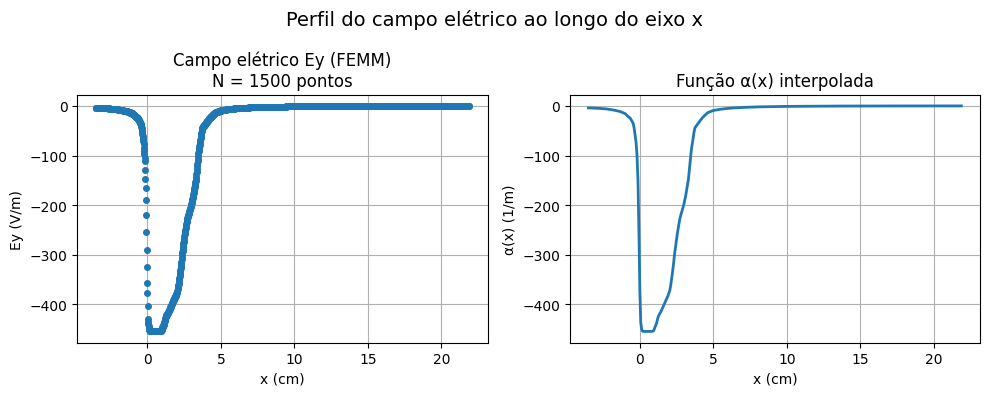

In [ ]:
#@title Visualização do campo

# ================= EIXO PARA INTERPOLAÇÃO =================
# Cria 400 pontos igualmente espaçados no domínio de x (em metros)
# Usado para visualizar a função contínua α(x)
x_plot = np.linspace(min(xsim), max(xsim), 400)

# ================= CONVERSÃO DE UNIDADES =================
# Converter de metros para centímetros para exibição
xsim_cm = xsim * 100
x_plot_cm = x_plot * 100

# ================= PLOT =================
plt.figure(figsize=(10,4))

# -------- Campo (dados discretos do FEMM) --------
plt.subplot(1,2,1)
plt.plot(
    xsim_cm, Esim,
    marker='o',
    linestyle='None',
    markersize=4
)
plt.xlabel("x (cm)")
plt.ylabel("Ey (V/m)")
plt.title(f"Campo elétrico Ey (FEMM)\nN = {len(xsim)} pontos")
plt.grid()

# -------- Alfa (função contínua interpolada) --------
plt.subplot(1,2,2)
plt.plot(
    x_plot_cm,
    alfafunc(x_plot),
    linestyle='-',
    linewidth=2
)
plt.xlabel("x (cm)")
plt.ylabel("α(x) (1/m)")
plt.title("Função α(x) interpolada")
plt.grid()

# -------- Título geral --------
plt.suptitle("Perfil do campo elétrico ao longo do eixo x", fontsize=14)

plt.tight_layout()
plt.show()

## 6. Simulação da trajetória do elétron
Integração da equação de movimento sob o campo elétrico.

In [ ]:
#@title Simulação da trajetória

x = np.arange(x_ini, x_tela + dx, dx)

yVp = np.zeros((len(Vacfixo), len(Vp)))

# ================= LOOP PRINCIPAL =================
for k, Vac in enumerate(Vacfixo):

    dt = dx * np.sqrt(m / (2 * q * Vac))

    for j, Vp_val in enumerate(Vp):

        y = 0.0
        vy = 0.0

        for x_val in x:
            E_val = float(alfafunc(x_val)) * Vp_val
            ay = -q * E_val / m  # elétron

            y += vy*dt + 0.5*ay*dt**2
            vy += ay*dt

        # yVp[k, j] armazena diretamente a posição do elétron na tela
        yVp[k, j] = y

print("Ordem de grandeza de y:", np.max(np.abs(yVp)))

Ordem de grandeza de y: 0.07615485089304454


## 7. Ajuste linear e comparação com experimento

Visualização da simulação e dos dados experimentais.

### 7.1 Aplicação do MMQ (com ODR) e visualização final.


Tentando carregar dados experimentais...
Formato esperado do CSV: Vp, y, sVp, sy
✔ Dados experimentais detectados, carregados e validados com sucesso.
Formato utilizado: Vp, y, sVp, sy
Unidade original de y e sy no CSV: m
Unidade usada no gráfico: cm


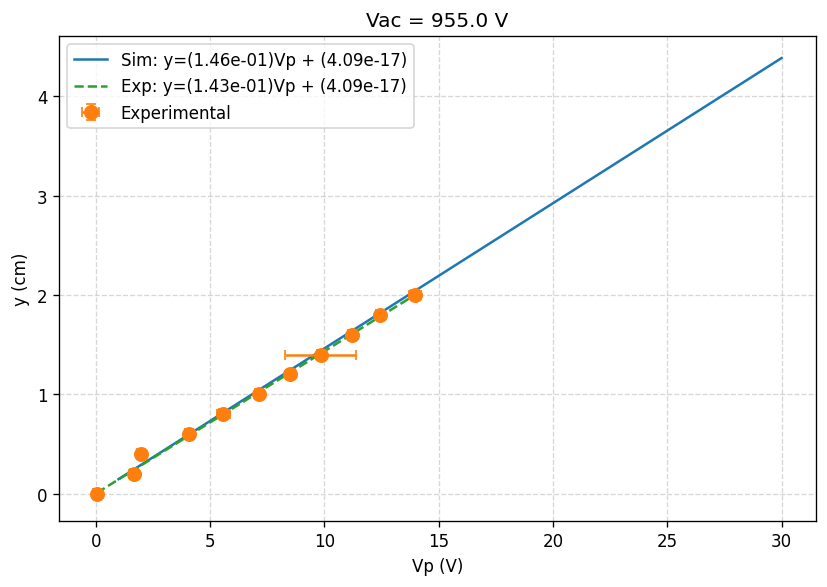


=== MMQ (Simulação) ===
Modelo: y = a·Vp + b

a = 1.4620e-01 cm/V
b = 4.0916e-17 cm
R² = 1.000000
Resíduo quadrático = 3.3261e-28

=== Dados Experimentais Carregados ===
Unidade original de y e sy no CSV: m
Unidade usada nos cálculos e no gráfico: cm

Pontos experimentais:
Vp = 0.05 ± 0.15 V | y = 0.000 ± 0.050 cm
Vp = 1.67 ± 0.22 V | y = 0.200 ± 0.050 cm
Vp = 2.000 ± 0.010 V | y = 0.400 ± 0.050 cm
Vp = 4.100 ± 0.020 V | y = 0.600 ± 0.050 cm
Vp = 5.59 ± 0.30 V | y = 0.800 ± 0.050 cm
Vp = 7.13 ± 0.13 V | y = 1.000 ± 0.050 cm
Vp = 8.52 ± 0.10 V | y = 1.200 ± 0.050 cm
Vp = 9.8 ± 1.6 V | y = 1.400 ± 0.050 cm
Vp = 11.210 ± 0.090 V | y = 1.600 ± 0.050 cm
Vp = 12.44 ± 0.18 V | y = 1.800 ± 0.050 cm
Vp = 13.97 ± 0.28 V | y = 2.000 ± 0.050 cm

=== MMQ/ODR (Experimental) ===
Modelo: y = a·Vp + b

a = (1.4332e-01 ± 1.72e-03) cm/V
b = (4.0916e-17 ± 0.00e+00) cm

Qualidade do ajuste:
R² aproximado em y = 0.996362
Resíduo quadrático em y = 1.6006e-02


In [98]:
#@title Gráfico y vs Vp com MMQ (simulação + experimental opcional)


# ================= CONFIGURAÇÕES GERAIS =================
csv_exp_vac_fixo = arquivo_vac_fixo

    # Vacfix define qual tensão de aceleração será mantida fixa
    # para gerar o gráfico y vs Vp.
    #
    # Por padrão, usamos o último valor da lista/array Vacfixo.
    # Se quiser escolher outro valor manualmente, substitua por algo como:
    # Vacfix = 600
Vacfix = Vacfixo[-1]

    # Unidade usada no CSV experimental para as colunas y e sy.
    #
    # Use:
    # "m"  → se y e sy estiverem em metros
    # "cm" → se y e sy estiverem em centímetros
    # "mm" → se y e sy estiverem em milímetros
    #
    # Observação:
    # A posição experimental y e sua incerteza sy devem estar sempre na mesma unidade.
    # Se y estiver em metros, sy também deve estar em metros.
    # Se y estiver em cm, sy também deve estar em cm.
    # Se y estiver em mm, sy também deve estar em mm.
    #
    # O gráfico final é exibido em cm, portanto os dados serão convertidos para cm
    # quando necessário.
unidade_y_csv = "m"

    # Tamanho visual dos pontos experimentais.
    # O matplotlib usa markersize para o diâmetro visual do marcador,
    # por isso usamos tamanho_ponto/5 no plt.errorbar.
tamanho_ponto = 40

    # Escolha se deseja mostrar o ponto central nos dados experimentais.
    # True  → mostra ponto + barra de erro
    # False → mostra apenas as barras de erro
mostrar_ponto_experimental = True

    # Escolha quais formatos de arquivo deseja exportar.
exportar_svg = False
exportar_pdf = False
exportar_png = False

# O código verifica automaticamente a existência do arquivo CSV acima.
#
# Formato esperado do CSV, com cabeçalho:
#
# Vp  → tensão nas placas defletoras (V)
# y   → posição experimental do feixe, na unidade definida por unidade_y_csv
# sVp → incerteza em Vp (V), em termos de sigma
# sy  → incerteza em y, na mesma unidade de y
#
# A ordem das colunas é livre, mas os nomes precisam ser exatamente:
# Vp, y, sVp, sy
#
# Exemplo, caso unidade_y_csv = "cm":
# Vp,y,sVp,sy
# 10,1.2,0.1,0.05
# 20,2.4,0.1,0.05
#
# Exemplo, caso unidade_y_csv = "m":
# Vp,y,sVp,sy
# 10,0.012,0.1,0.0005
# 20,0.024,0.1,0.0005
#
# Exemplo, caso unidade_y_csv = "mm":
# Vp,y,sVp,sy
# 10,12,0.1,0.5
# 20,24,0.1,0.5
#
# Observação importante:
# sVp é uma incerteza na tensão das placas defletoras, isto é, na variável do eixo x.
# sy é uma incerteza na posição vertical y, isto é, na variável do eixo y.
# Por isso, no gráfico y vs Vp:
#
# sVp → entra como xerr
# sy  → entra como yerr
#
# Além disso, no ajuste experimental por ODR, sVp e sy entram diretamente no modelo
# para ponderar o ajuste considerando incertezas nas duas direções.


# ================= FUNÇÃO: FATOR DE CONVERSÃO DE y E sy =================
def obter_fator_y_para_cm(unidade_y_csv):
    """
    Retorna o fator de conversão da unidade usada no CSV para centímetros.

    O gráfico final trabalha com y em cm. Portanto, independentemente da unidade
    usada no CSV, os valores experimentais de y e sy serão convertidos para cm.

    Exemplos:
    - Se o CSV está em metros:      1 m  = 100 cm
    - Se o CSV está em centímetros: 1 cm = 1 cm
    - Se o CSV está em milímetros:  1 mm = 0.1 cm
    """

    # Remove espaços extras e padroniza letras maiúsculas/minúsculas.
    unidade = str(unidade_y_csv).strip().lower()

    fatores_para_cm = {
        "m": 100,
        "cm": 1,
        "mm": 0.1
    }

    if unidade not in fatores_para_cm:
        unidades_validas = ", ".join(fatores_para_cm.keys())
        raise ValueError(
            f"A variável 'unidade_y_csv' deve ser uma das seguintes: {unidades_validas}."
        )

    return fatores_para_cm[unidade]


# ================= FUNÇÃO: CARREGAMENTO E VALIDAÇÃO DO CSV =================
def carregar_csv_vac_fixo(caminho_csv, unidade_y_csv):
    """
    Lê e valida o CSV experimental para o gráfico y vs Vp com Vac fixo.

    A função centraliza a lógica de leitura do arquivo para deixar o restante
    do código mais limpo. Ela verifica:

    1. Se o arquivo existe;
    2. Se o arquivo não está vazio;
    3. Se todas as colunas obrigatórias estão presentes;
    4. Se os valores das colunas podem ser interpretados como números;
    5. Se as incertezas são positivas;
    6. Se há pontos suficientes para um ajuste linear;
    7. Se a unidade de y e sy foi informada corretamente.

    Retorna:
    - df_exp: DataFrame com os dados experimentais validados;
    - usando_experimental: True se o CSV foi carregado corretamente, False caso contrário.
    """

    colunas_obrigatorias = ["Vp", "y", "sVp", "sy"]

    try:
        # -------- LEITURA DO CSV --------
        df_exp = pd.read_csv(caminho_csv)

        # -------- VERIFICAÇÃO DE ARQUIVO SEM DADOS --------
        if df_exp.empty:
            raise pd.errors.EmptyDataError("O arquivo CSV não possui linhas de dados.")

        # -------- VALIDAÇÃO DAS COLUNAS --------
        colunas_faltantes = [
            coluna for coluna in colunas_obrigatorias
            if coluna not in df_exp.columns
        ]

        if colunas_faltantes:
            raise ValueError(
                "Colunas obrigatórias ausentes: "
                + ", ".join(colunas_faltantes)
            )

        # -------- CONVERSÃO NUMÉRICA --------
        # Mesmo que o CSV seja lido, alguns valores podem vir como texto.
        # O parâmetro errors='coerce' transforma valores inválidos em NaN,
        # permitindo detectar problemas de preenchimento.
        for coluna in colunas_obrigatorias:
            df_exp[coluna] = pd.to_numeric(df_exp[coluna], errors="coerce")

        # -------- VERIFICAÇÃO DE VALORES INVÁLIDOS --------
        valores_invalidos = df_exp[colunas_obrigatorias].isna().sum()
        valores_invalidos = valores_invalidos[valores_invalidos > 0]

        if not valores_invalidos.empty:
            msg = ", ".join(
                [f"{coluna}: {n}" for coluna, n in valores_invalidos.items()]
            )
            raise ValueError(
                "Foram encontrados valores ausentes ou não numéricos nas colunas: "
                + msg
            )

        # -------- VERIFICAÇÃO DA UNIDADE DE y E sy --------
        # A variável unidade_y_csv define a unidade usada no CSV experimental
        # para as colunas y e sy.
        #
        # Como o gráfico final é exibido em cm, os dados experimentais também
        # precisam ficar em cm antes da plotagem e antes da comparação com a simulação.
        fator_y_csv_para_cm = obter_fator_y_para_cm(unidade_y_csv)

        # -------- VERIFICAÇÃO FÍSICA BÁSICA --------
        # Para o ajuste por ODR, as incertezas usadas como sigma devem ser positivas.
        # Valores iguais a zero causam pesos infinitos no ajuste, o que não é adequado.
        if (df_exp["sVp"] <= 0).any():
            raise ValueError("A coluna 'sVp' deve conter apenas incertezas positivas.")

        if (df_exp["sy"] <= 0).any():
            raise ValueError("A coluna 'sy' deve conter apenas incertezas positivas.")

        # Para ajustar uma reta, são necessários pelo menos dois pontos.
        if len(df_exp) < 2:
            raise ValueError("São necessários pelo menos dois pontos para o ajuste linear.")

        # Se todos os valores de Vp forem iguais, não é possível ajustar y = a·Vp + b.
        if np.isclose(np.ptp(df_exp["Vp"].values), 0):
            raise ValueError("A coluna 'Vp' precisa ter pelo menos dois valores distintos.")

        # -------- CONVERSÃO DE UNIDADES DE y E sy --------
        # O gráfico trabalha com y em cm, pois os dados simulados também são
        # convertidos de m para cm antes da plotagem.
        #
        # Portanto, convertemos os valores experimentais de y e sy para cm.
        # A mesma conversão precisa ser aplicada à incerteza, pois sy representa
        # uma variação na própria grandeza y.
        #
        # Exemplos:
        # unidade_y_csv = "m"  → multiplica y e sy por 100
        # unidade_y_csv = "cm" → mantém y e sy como estão
        # unidade_y_csv = "mm" → multiplica y e sy por 0.1
        df_exp["y"] = df_exp["y"] * fator_y_csv_para_cm
        df_exp["sy"] = df_exp["sy"] * fator_y_csv_para_cm

        # -------- ORGANIZAÇÃO DOS DADOS --------
        # Ordenar por Vp deixa os resultados, o gráfico e o ajuste mais previsíveis.
        df_exp = df_exp.sort_values("Vp").reset_index(drop=True)

        print("✔ Dados experimentais detectados, carregados e validados com sucesso.")
        print("Formato utilizado: Vp, y, sVp, sy")
        print(f"Unidade original de y e sy no CSV: {unidade_y_csv}")
        print("Unidade usada no gráfico: cm")

        return df_exp, True

    except FileNotFoundError:
        print("\nℹ️ Arquivo experimental não encontrado.")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except pd.errors.EmptyDataError:
        print("\n⚠️ O arquivo CSV está vazio.")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except ValueError as e:
        print("\n⚠️ Problema no conteúdo do CSV:")
        print("→", e)
        print("→ Esperado: Vp, y, sVp, sy")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except Exception as e:
        print("\n⚠️ Erro inesperado ao processar os dados experimentais:")
        print("→", e)
        print("→ Apenas a simulação será exibida.")
        return None, False


# ================= FUNÇÃO: LOCALIZAÇÃO DO ÍNDICE DE Vac =================
def localizar_indice_vacfixo(Vacfixo, Vacfix):
    """
    Localiza o índice do valor de Vac usado para obter a curva simulada y vs Vp.

    No código original, a busca era feita com:

        idx = Vacfixo.index(Vacfix)

    Isso funciona quando Vacfixo é uma lista e quando o valor procurado existe
    exatamente na lista.

    Aqui usamos uma forma mais geral:
    - convertemos Vacfixo para array numpy;
    - buscamos o valor mais próximo de Vacfix;
    - avisamos caso o valor encontrado não seja exatamente igual.

    Isso evita problemas quando Vacfixo for array numpy ou quando houver pequenas
    diferenças numéricas de ponto flutuante.
    """

    Vac_array = np.asarray(Vacfixo, dtype=float)

    idx = np.argmin(np.abs(Vac_array - Vacfix))
    Vac_encontrado = Vac_array[idx]

    if not np.isclose(Vac_encontrado, Vacfix):
        print("\n⚠️ Vacfix exato não encontrado em Vacfixo.")
        print(f"→ Valor solicitado: {Vacfix} V")
        print(f"→ Valor mais próximo usado: {Vac_encontrado} V")

    return idx


# ================= FUNÇÃO: MMQ LINEAR DA SIMULAÇÃO =================
def ajustar_reta_simulacao(Vp_sim, y_sim):
    """
    Ajusta uma reta aos dados simulados usando np.polyfit.

    Modelo utilizado:

        y = a·Vp + b

    Como a simulação não possui incertezas associadas a cada ponto neste bloco,
    usamos o ajuste linear usual por mínimos quadrados.

    Retorna:
    - a_sim: coeficiente angular da reta simulada;
    - b_sim: coeficiente linear da reta simulada;
    - y_fit_sim: valores ajustados nos próprios pontos de Vp;
    - r2_sim: coeficiente de determinação;
    - ss_res_sim: soma dos quadrados dos resíduos.
    """

    Vp_sim = np.asarray(Vp_sim, dtype=float)
    y_sim = np.asarray(y_sim, dtype=float)

    if len(Vp_sim) != len(y_sim):
        raise ValueError("Vp e y_sim precisam ter o mesmo número de pontos.")

    if len(Vp_sim) < 2:
        raise ValueError("São necessários pelo menos dois pontos para o ajuste da simulação.")

    if np.isclose(np.ptp(Vp_sim), 0):
        raise ValueError("Vp precisa ter pelo menos dois valores distintos.")

    coef_sim = np.polyfit(Vp_sim, y_sim, 1)
    a_sim, b_sim = coef_sim

    y_fit_sim = a_sim * Vp_sim + b_sim

    # Métricas do ajuste.
    res_sim = y_sim - y_fit_sim
    ss_res_sim = np.sum(res_sim**2)
    ss_tot_sim = np.sum((y_sim - np.mean(y_sim))**2)

    if np.isclose(ss_tot_sim, 0):
        r2_sim = np.nan
    else:
        r2_sim = 1 - ss_res_sim / ss_tot_sim

    return a_sim, b_sim, y_fit_sim, r2_sim, ss_res_sim


# ================= FUNÇÃO: MMQ/ODR EXPERIMENTAL =================
def ajustar_reta_experimental_odr(Vp_exp, y_exp, sVp_exp, sy_exp, beta0):
    """
    Ajusta uma reta aos dados experimentais usando ODR.

    ODR significa Orthogonal Distance Regression.
    Ele é adequado aqui porque os dados experimentais possuem incerteza tanto em:

    - Vp, representada por sVp;
    - y, representada por sy.

    Modelo utilizado:

        y = a·Vp + b

    O parâmetro beta0 fornece um chute inicial para o ajuste.
    Neste código, usamos os coeficientes da simulação como chute inicial,
    pois eles já descrevem aproximadamente a relação esperada entre y e Vp.

    Retorna:
    - a_exp, b_exp: coeficientes ajustados;
    - erro_a_exp, erro_b_exp: incertezas estimadas dos coeficientes;
    - Vp_lin: eixo auxiliar para desenhar a reta ajustada;
    - y_fit_exp: reta ajustada nos pontos de Vp_lin;
    - r2_exp: estimativa de R² calculada na direção vertical y;
    - ss_res_exp: soma dos quadrados dos resíduos em y;
    - resultado: objeto completo retornado pelo ODR.
    """

    if "mmq" not in globals():
        raise ImportError(
            "Execute primeiro a célula inicial de imports: from scipy import odr as mmq."
        )

    Vp_exp = np.asarray(Vp_exp, dtype=float)
    y_exp = np.asarray(y_exp, dtype=float)
    sVp_exp = np.asarray(sVp_exp, dtype=float)
    sy_exp = np.asarray(sy_exp, dtype=float)

    # Modelo linear usado pelo ODR.
    # B[0] corresponde ao coeficiente angular a.
    # B[1] corresponde ao coeficiente linear b.
    def modelo(B, x):
        return B[0]*x + B[1]

    modelo_mmq = mmq.Model(modelo)

    dados_mmq = mmq.RealData(
        Vp_exp,
        y_exp,
        sx=sVp_exp,
        sy=sy_exp
    )

    ajuste = mmq.ODR(dados_mmq, modelo_mmq, beta0=beta0)
    resultado = ajuste.run()

    a_exp, b_exp = resultado.beta
    erro_a_exp, erro_b_exp = resultado.sd_beta

    # Linha ajustada para visualização no gráfico.
    Vp_lin = np.linspace(min(Vp_exp), max(Vp_exp), 200)
    y_fit_exp = a_exp * Vp_lin + b_exp

    # Métricas aproximadas na direção vertical y.
    # Observação:
    # O ajuste ODR minimiza distâncias considerando x e y, não apenas resíduos verticais.
    # Portanto, este R² deve ser interpretado como uma estimativa auxiliar,
    # útil para comparação visual e diagnóstico simples.
    y_fit_exp_data = a_exp * Vp_exp + b_exp
    res_exp = y_exp - y_fit_exp_data

    ss_res_exp = np.sum(res_exp**2)
    ss_tot_exp = np.sum((y_exp - np.mean(y_exp))**2)

    if np.isclose(ss_tot_exp, 0):
        r2_exp = np.nan
    else:
        r2_exp = 1 - ss_res_exp / ss_tot_exp

    return (
        a_exp,
        b_exp,
        erro_a_exp,
        erro_b_exp,
        Vp_lin,
        y_fit_exp,
        r2_exp,
        ss_res_exp,
        resultado
    )


# ================= FUNÇÃO: FORMATAÇÃO COM INCERTEZA =================
def formatar_valor_com_incerteza(valor, incerteza, sig=2):
    """
    Formata um valor com sua incerteza usando algarismos significativos.

    Essa função é útil para imprimir resultados experimentais de forma mais limpa,
    evitando casas decimais excessivas.

    Exemplo conceitual:
    1.23456 ± 0.0789  →  1.23 ± 0.08
    """

    if incerteza == 0 or np.isnan(incerteza):
        return f"{valor} ± {incerteza}"

    # Normaliza a incerteza para manter sig algarismos significativos.
    expoente = int(np.floor(np.log10(abs(incerteza))))
    fator = 10**(sig - 1 - expoente)
    inc = round(incerteza * fator) / fator

    # Detecta se a incerteza é efetivamente inteira.
    if np.isclose(inc, round(inc)):
        inc = round(inc)
        casas = 0
    else:
        expoente = int(np.floor(np.log10(abs(inc))))
        casas = max(0, -(expoente - (sig - 1)))

    # Formatação consistente do valor e da incerteza.
    if casas == 0:
        valor_fmt = f"{round(valor)}"
        inc_fmt = f"{int(inc)}"
    else:
        valor_fmt = f"{valor:.{casas}f}"
        inc_fmt = f"{inc:.{casas}f}"

    return f"{valor_fmt} ± {inc_fmt}"


# ================= SIMULAÇÃO =================
# Localiza o índice associado ao valor escolhido de Vac.
idx = localizar_indice_vacfixo(Vacfixo, Vacfix)

# Os valores simulados de y estão em metros.
# Para o gráfico e para a comparação com os dados experimentais,
# convertemos a simulação para centímetros.
y_vals = np.asarray(yVp[idx], dtype=float) * 100

# Também garantimos que Vp seja tratado como array numérico.
Vp_sim = np.asarray(Vp, dtype=float)

# Ajuste linear da simulação.
a_sim, b_sim, y_fit_sim, r2_sim, ss_res_sim = ajustar_reta_simulacao(Vp_sim, y_vals)


# ================= CARREGAMENTO DOS DADOS EXPERIMENTAIS =================
print("\nTentando carregar dados experimentais...")
print("Formato esperado do CSV: Vp, y, sVp, sy")

df_exp, dados_experimentais_carregados = carregar_csv_vac_fixo(
    csv_exp_vac_fixo,
    unidade_y_csv
)


# ================= PLOT =================
plt.figure(figsize=(7, 5), dpi=120)

# -------- PLOT DA SIMULAÇÃO --------
plt.plot(
    Vp_sim,
    y_fit_sim,
    '-',
    label=f"Sim: y=({a_sim:.2e})Vp + ({b_sim:.2e})"
)


# ================= DADOS EXPERIMENTAIS E MMQ/ODR =================
if dados_experimentais_carregados:

    # -------- EXTRAÇÃO DOS DADOS EXPERIMENTAIS --------
    # Neste ponto, y e sy já estão convertidos para cm pela função carregar_csv_vac_fixo.
    Vp_exp = df_exp["Vp"].values
    y_exp = df_exp["y"].values
    sVp_exp = df_exp["sVp"].values
    sy_exp = df_exp["sy"].values

    # -------- PLOT EXPERIMENTAL --------
    # sVp entra como barra de erro horizontal, pois Vp está no eixo x.
    # sy entra como barra de erro vertical, pois y está no eixo y.
    formato = 'o' if mostrar_ponto_experimental else 'none'

    plt.errorbar(
        Vp_exp,
        y_exp,
        xerr=sVp_exp,
        yerr=sy_exp,
        fmt=formato,
        markersize=tamanho_ponto/5,
        capsize=3,
        label='Experimental'
    )

    try:
        # -------- MMQ/ODR EXPERIMENTAL --------
        (
            a_exp,
            b_exp,
            erro_a_exp,
            erro_b_exp,
            Vp_lin,
            y_fit_exp,
            r2_exp,
            ss_res_exp,
            resultado_odr
        ) = ajustar_reta_experimental_odr(
            Vp_exp,
            y_exp,
            sVp_exp,
            sy_exp,
            beta0=[a_sim, b_sim]
        )

        plt.plot(
            Vp_lin,
            y_fit_exp,
            '--',
            label=f"Exp: y=({a_exp:.2e})Vp + ({b_exp:.2e})"
        )

        ajuste_experimental_realizado = True

    except Exception as e:
        print("\n⚠️ Não foi possível realizar o ajuste ODR experimental:")
        print("→", e)
        print("→ Os pontos experimentais serão exibidos, mas sem reta ajustada.")
        ajuste_experimental_realizado = False

else:
    ajuste_experimental_realizado = False


# ================= FORMATAÇÃO DO GRÁFICO =================
plt.title(f'Vac = {Vacfix} V')
plt.xlabel('Vp (V)')
plt.ylabel('y (cm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()


# ================= EXPORTAÇÃO DO GRÁFICO =================
# Os arquivos são exportados apenas se as variáveis correspondentes
# estiverem marcadas como True.

if exportar_svg:
    plt.savefig("grafico_y_vs_Vp.svg", format="svg", bbox_inches="tight")

if exportar_pdf:
    plt.savefig("grafico_y_vs_Vp.pdf", format="pdf", bbox_inches="tight")

if exportar_png:
    plt.savefig(
        "grafico_y_vs_Vp.png",
        format="png",
        dpi=1000,
        bbox_inches="tight"
    )

plt.show()


# ================= RESULTADOS =================

# -------- SIMULAÇÃO --------
print("\n=== MMQ (Simulação) ===")
print("Modelo: y = a·Vp + b\n")
print(f"a = {a_sim:.4e} cm/V")
print(f"b = {b_sim:.4e} cm")
print(f"R² = {r2_sim:.6f}")
print(f"Resíduo quadrático = {ss_res_sim:.4e}")


# -------- EXPERIMENTAL --------
if dados_experimentais_carregados:

    print("\n=== Dados Experimentais Carregados ===")
    print(f"Unidade original de y e sy no CSV: {unidade_y_csv}")
    print("Unidade usada nos cálculos e no gráfico: cm")

    print("\nPontos experimentais:")
    for _, row in df_exp.iterrows():
        vp_txt = formatar_valor_com_incerteza(row["Vp"], row["sVp"])
        y_txt = formatar_valor_com_incerteza(row["y"], row["sy"])

        print(f"Vp = {vp_txt} V | y = {y_txt} cm")

    if ajuste_experimental_realizado:
        print("\n=== MMQ/ODR (Experimental) ===")
        print("Modelo: y = a·Vp + b\n")

        print(f"a = ({a_exp:.4e} ± {erro_a_exp:.2e}) cm/V")
        print(f"b = ({b_exp:.4e} ± {erro_b_exp:.2e}) cm")

        print("\nQualidade do ajuste:")
        print(f"R² aproximado em y = {r2_exp:.6f}")
        print(f"Resíduo quadrático em y = {ss_res_exp:.4e}")

    else:
        print("\n(Dados experimentais exibidos, mas ajuste ODR não realizado)")

else:
    print("\n(Dados experimentais não utilizados nesta execução)")

### 7.2 Conclusões

- O modelo reproduz o comportamento linear observado
- O campo obtido no FEMM é consistente com a deflexão
- A inclusão de incertezas melhora o ajuste experimental

## 8. Trajetória do elétron e impacto na tela

Visualização $(x,y)$ do elétron e marcações na tela dos dados experimentais.

✔ Dados experimentais detectados, carregados e validados com sucesso.
Formato utilizado: Vac, y, sy, sVac
Unidade original de y e sy no CSV: cm
Unidade usada no gráfico: cm


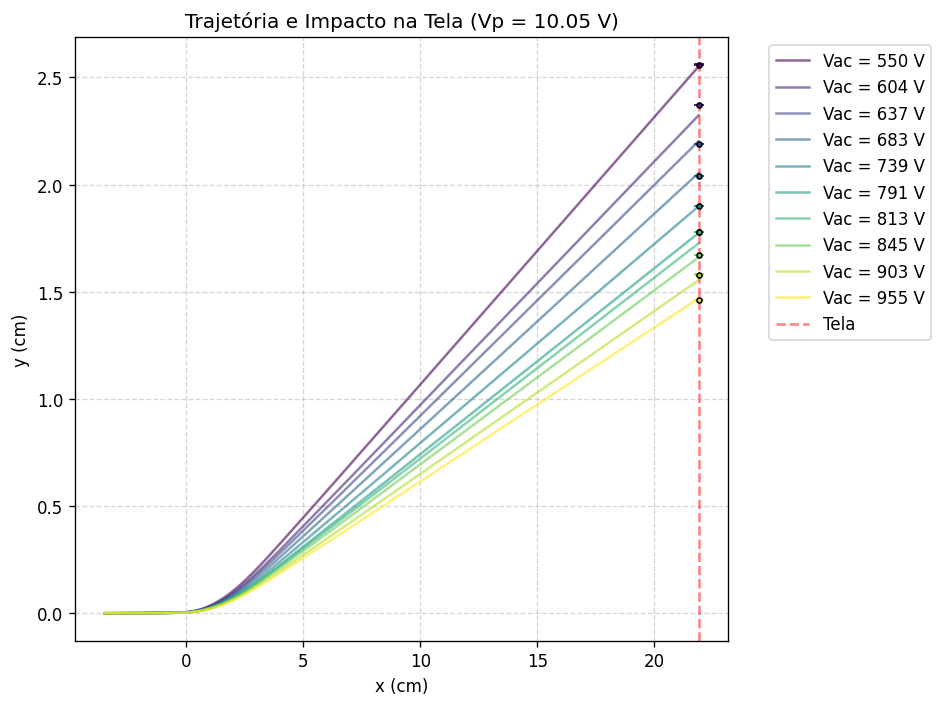


=== Resultados na Tela (x = 21.90 cm) ===
Vac = 550.0 ± 5.5 V | Sim: 2.551 cm | Exp: 2.56000 ± 0.00050 cm
Vac = 604 ± 6 V | Sim: 2.323 cm | Exp: 2.37000 ± 0.00050 cm
Vac = 637.0 ± 6.4 V | Sim: 2.203 cm | Exp: 2.19000 ± 0.00050 cm
Vac = 683.0 ± 6.8 V | Sim: 2.054 cm | Exp: 2.04000 ± 0.00050 cm
Vac = 739.0 ± 7.4 V | Sim: 1.899 cm | Exp: 1.90000 ± 0.00050 cm
Vac = 791.0 ± 7.9 V | Sim: 1.774 cm | Exp: 1.78000 ± 0.00050 cm
Vac = 813.0 ± 8.1 V | Sim: 1.726 cm | Exp: 1.78000 ± 0.00050 cm
Vac = 845.0 ± 8.4 V | Sim: 1.661 cm | Exp: 1.67000 ± 0.00050 cm
Vac = 903 ± 9 V | Sim: 1.554 cm | Exp: 1.58000 ± 0.00050 cm
Vac = 955.0 ± 9.6 V | Sim: 1.469 cm | Exp: 1.46000 ± 0.00050 cm


In [95]:
#@title Trajetória do elétron + impacto na tela

# ================= CONFIGURAÇÕES GERAIS =================
csv_exp_Vp_fixo = arquivo_tela

    # Vptraj define a tensão nas placas defletoras usada para calcular a trajetória.
Vptraj = Vptraj

    # Unidade usada no CSV experimental para as colunas y e sy.
    #
    # Use:
    # "m"  → se y e sy estiverem em metros
    # "cm" → se y e sy estiverem em centímetros
    # "mm" → se y e sy estiverem em milímetros
    #
    # Observação:
    # A posição experimental y e sua incerteza sy devem estar sempre na mesma unidade.
    # Se y estiver em metros, sy também deve estar em metros.
    # Se y estiver em cm, sy também deve estar em cm.
    # Se y estiver em mm, sy também deve estar em mm.
    #
    # O gráfico final é exibido em cm, portanto os dados serão convertidos para cm
    # quando necessário.
unidade_y_csv = "cm"

    # Escolha se deseja mostrar o ponto central nos dados experimentais.
    # True  → mostra ponto + barra de erro
    # False → mostra apenas as barras de erro
mostrar_ponto_experimental = True

    # Escolha quais formatos de arquivo deseja exportar.
exportar_svg = False
exportar_pdf = False
exportar_png = False

# O código verifica automaticamente a existência do arquivo CSV acima.
#
# Formato esperado do CSV, com cabeçalho:
#
# Vac  → tensão de aceleração (V)
# y    → posição experimental do feixe na tela, na unidade definida por unidade_y_csv
# sy   → incerteza em y, na mesma unidade de y
# sVac → incerteza em Vac (V), em termos de sigma
#
# A ordem das colunas é livre, mas os nomes precisam ser exatamente:
# Vac, y, sy, sVac
#
# Exemplo, caso unidade_y_csv = "cm":
# Vac,y,sy,sVac
# 600,2.8,0.1,5
# 800,2.0,0.1,5
#
# Exemplo, caso unidade_y_csv = "m":
# Vac,y,sy,sVac
# 600,0.028,0.001,5
# 800,0.020,0.001,5
#
# Exemplo, caso unidade_y_csv = "mm":
# Vac,y,sy,sVac
# 600,28,1,5
# 800,20,1,5
#
# Observação importante:
# sVac é uma incerteza na tensão de aceleração, não na posição horizontal x.
# Por isso, ela não deve ser colocada diretamente como xerr no gráfico de trajetória,
# pois o eixo horizontal do gráfico é x (cm), e não Vac (V).
# Para transformar sVac em incerteza vertical no impacto, seria necessário propagar
# essa incerteza pela simulação, recalculando a trajetória para Vac ± sVac.

# Caso você tenha uma incerteza real da posição da tela em cm, ela poderia ser usada aqui.
# Por padrão, deixamos como None para não criar uma barra de erro horizontal artificial.
incerteza_x_tela_cm = None


# ================= FUNÇÃO: FATOR DE CONVERSÃO DE y E sy =================
def obter_fator_y_para_cm(unidade_y_csv):
    """
    Retorna o fator de conversão da unidade usada no CSV para centímetros.

    O gráfico final trabalha com y em cm. Portanto, independentemente da unidade
    usada no CSV, os valores experimentais de y e sy serão convertidos para cm.

    Exemplos:
    - Se o CSV está em metros:      1 m  = 100 cm
    - Se o CSV está em centímetros: 1 cm = 1 cm
    - Se o CSV está em milímetros:  1 mm = 0.1 cm
    """

    # Remove espaços extras e padroniza letras maiúsculas/minúsculas.
    unidade = str(unidade_y_csv).strip().lower()

    fatores_para_cm = {
        "m": 100,
        "cm": 1,
        "mm": 0.1
    }

    if unidade not in fatores_para_cm:
        unidades_validas = ", ".join(fatores_para_cm.keys())
        raise ValueError(
            f"A variável 'unidade_y_csv' deve ser uma das seguintes: {unidades_validas}."
        )

    return fatores_para_cm[unidade]


# ================= FUNÇÃO: CARREGAMENTO E VALIDAÇÃO DO CSV =================
def carregar_csv_tela(caminho_csv, unidade_y_csv):
    """
    Lê e valida o CSV experimental da tela.

    A função centraliza a lógica de leitura do arquivo para deixar o restante
    do código mais limpo. Ela verifica:

    1. Se o arquivo existe;
    2. Se o arquivo não está vazio;
    3. Se todas as colunas obrigatórias estão presentes;
    4. Se os valores das colunas podem ser interpretados como números;
    5. Se as incertezas são não negativas;
    6. Se Vac é positivo, pois Vac aparece dentro de uma raiz quadrada na simulação;
    7. Se a unidade de y e sy foi informada corretamente.

    Retorna:
    - df_exp: DataFrame com os dados experimentais validados;
    - usando_experimental: True se o CSV foi carregado corretamente, False caso contrário.
    """

    colunas_obrigatorias = ["Vac", "y", "sy", "sVac"]

    try:
        # -------- LEITURA DO CSV --------
        df_exp = pd.read_csv(caminho_csv)

        # -------- VERIFICAÇÃO DE ARQUIVO SEM DADOS --------
        if df_exp.empty:
            raise pd.errors.EmptyDataError("O arquivo CSV não possui linhas de dados.")

        # -------- VALIDAÇÃO DAS COLUNAS --------
        colunas_faltantes = [
            coluna for coluna in colunas_obrigatorias
            if coluna not in df_exp.columns
        ]

        if colunas_faltantes:
            raise ValueError(
                "Colunas obrigatórias ausentes: "
                + ", ".join(colunas_faltantes)
            )

        # -------- CONVERSÃO NUMÉRICA --------
        # Mesmo que o CSV seja lido, alguns valores podem vir como texto.
        # O parâmetro errors='coerce' transforma valores inválidos em NaN,
        # permitindo detectar problemas de preenchimento.
        for coluna in colunas_obrigatorias:
            df_exp[coluna] = pd.to_numeric(df_exp[coluna], errors="coerce")

        # -------- VERIFICAÇÃO DE VALORES INVÁLIDOS --------
        valores_invalidos = df_exp[colunas_obrigatorias].isna().sum()
        valores_invalidos = valores_invalidos[valores_invalidos > 0]

        if not valores_invalidos.empty:
            msg = ", ".join(
                [f"{coluna}: {n}" for coluna, n in valores_invalidos.items()]
            )
            raise ValueError(
                "Foram encontrados valores ausentes ou não numéricos nas colunas: "
                + msg
            )

        # -------- VERIFICAÇÃO DA UNIDADE DE y E sy --------
        # A variável unidade_y_csv define a unidade usada no CSV experimental
        # para as colunas y e sy.
        #
        # Como o gráfico final é exibido em cm, os dados experimentais também
        # precisam ficar em cm antes da plotagem e antes da comparação com a simulação.
        fator_y_csv_para_cm = obter_fator_y_para_cm(unidade_y_csv)

        # -------- VERIFICAÇÃO FÍSICA BÁSICA --------
        # Vac deve ser positivo, pois entra na expressão:
        # dt = dx * sqrt(m / (2*q*Vac))
        if (df_exp["Vac"] <= 0).any():
            raise ValueError("A coluna 'Vac' deve conter apenas valores positivos.")

        # As incertezas sy e sVac devem ser maiores ou iguais a zero.
        if (df_exp["sy"] < 0).any():
            raise ValueError("A coluna 'sy' não pode conter incertezas negativas.")

        if (df_exp["sVac"] < 0).any():
            raise ValueError("A coluna 'sVac' não pode conter incertezas negativas.")

        # -------- CONVERSÃO DE UNIDADES DE y E sy --------
        # O gráfico trabalha com y em cm, pois a trajetória simulada também é
        # convertida de m para cm antes da plotagem.
        #
        # Portanto, convertemos os valores experimentais de y e sy para cm.
        # A mesma conversão precisa ser aplicada à incerteza, pois sy representa
        # uma variação na própria grandeza y.
        #
        # Exemplos:
        # unidade_y_csv = "m"  → multiplica y e sy por 100
        # unidade_y_csv = "cm" → mantém y e sy como estão
        # unidade_y_csv = "mm" → multiplica y e sy por 0.1
        df_exp["y"] = df_exp["y"] * fator_y_csv_para_cm
        df_exp["sy"] = df_exp["sy"] * fator_y_csv_para_cm

        # -------- ORGANIZAÇÃO DOS DADOS --------
        # Ordenar por Vac deixa os resultados e o gráfico mais previsíveis.
        df_exp = df_exp.sort_values("Vac").reset_index(drop=True)

        print("✔ Dados experimentais detectados, carregados e validados com sucesso.")
        print("Formato utilizado: Vac, y, sy, sVac")
        print(f"Unidade original de y e sy no CSV: {unidade_y_csv}")
        print("Unidade usada no gráfico: cm")

        return df_exp, True

    except FileNotFoundError:
        print("\nℹ️ Arquivo experimental não encontrado.")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except pd.errors.EmptyDataError:
        print("\n⚠️ O arquivo CSV está vazio.")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except ValueError as e:
        print("\n⚠️ Problema no conteúdo do CSV:")
        print("→", e)
        print("→ Esperado: Vac, y, sy, sVac")
        print("→ Apenas a simulação será exibida.")
        return None, False

    except Exception as e:
        print("\n⚠️ Erro inesperado ao processar os dados experimentais:")
        print("→", e)
        print("→ Apenas a simulação será exibida.")
        return None, False


# ================= FUNÇÃO: CÁLCULO DA TRAJETÓRIA =================
def calcular_trajetoria_eletron(Vac_val, Vptraj):
    """
    Calcula a trajetória vertical y(x) do elétron para um dado Vac e Vptraj.

    A integração é feita por passos sucessivos ao longo de x.
    Em cada passo:

    1. Calcula-se o campo elétrico E enquanto o elétron está entre as placas;
    2. Calcula-se o intervalo de tempo dt usando a velocidade horizontal;
    3. Atualizam-se a posição vertical y e a velocidade vertical vy.

    O método usado é uma integração direta tipo Euler com termo de aceleração:

        y = y + vy*dt + 0.5*ay*dt²
        vy = vy + ay*dt

    Retorna:
    - y_traj_cm: array com a trajetória vertical em cm;
    - y_tela_sim: valor final de y na tela, em cm.
    """

    vy = 0.0
    y_pos = 0.0
    y_traj = []

    for xi in x:
        # O campo elétrico só atua até o limite das placas.
        # Depois das placas, o elétron segue com velocidade vertical constante.
        if xi < np.max(xsim):
            E = alfafunc(xi) * Vptraj
        else:
            E = 0.0

        # Cálculo do passo de tempo baseado na velocidade horizontal.
        # A velocidade horizontal depende da tensão de aceleração Vac.
        dt = dx * np.sqrt(m / (2 * q * Vac_val))

        # Aceleração vertical causada pelo campo elétrico.
        # O sinal negativo aparece porque o elétron possui carga negativa
        # quando q é tratado como módulo positivo.
        ay = -q * E / m

        # Atualização da posição e da velocidade vertical.
        y_pos = y_pos + vy*dt + 0.5*ay*dt**2
        vy = vy + ay*dt

        y_traj.append(y_pos)

    # Conversão de m para cm para visualização no gráfico.
    # Esta conversão é da simulação, não do CSV.
    # Por isso ela continua fixa em *100.
    y_traj_cm = np.array(y_traj) * 100

    # Posição vertical final do feixe na tela.
    y_tela_sim = y_traj_cm[-1]

    return y_traj_cm, y_tela_sim


# ================= ÍNDICE DO Vp =================
# Localiza o valor de Vp mais próximo do desejado dentro do array definido no início.
# Isso é útil quando Vptraj não coincide exatamente com um dos valores discretos de Vp.
idx_vp = np.argmin(np.abs(Vp - Vptraj))


# ================= CONVERSÃO DE UNIDADES =================
# O array x está em metros na simulação.
# Para o gráfico, convertemos x para cm.
x_cm = x * 100


# ================= CARREGAMENTO DOS DADOS EXPERIMENTAIS =================
df_exp, usando_experimental = carregar_csv_tela(csv_exp_Vp_fixo, unidade_y_csv)

if usando_experimental:
    # Usa os valores de Vac presentes no CSV experimental.
    # np.unique evita repetir a mesma trajetória simulada caso haja mais de uma
    # medida experimental para o mesmo Vac.
    Vac_plot = np.unique(df_exp["Vac"].values)
else:
    # Caso não haja CSV válido, usa os valores definidos na simulação.
    Vac_plot = np.array(Vacfixo, dtype=float)


# ================= PLOT DA TRAJETÓRIA =================
plt.figure(figsize=(8, 6), dpi=120)

# O figsize é exibido em polegadas.
# dpi significa "dots per inch", isto é, pixels por polegada.
# Quanto maior o dpi, maior a resolução visual da figura.

cores = plt.cm.viridis(np.linspace(0, 1, len(Vac_plot)))

# Dicionário para armazenar os resultados simulados finais.
# A chave será Vac e o valor será y na tela.
y_tela_sim_final = {}

for i, Vac_val in enumerate(Vac_plot):

    # -------- CÁLCULO DA TRAJETÓRIA SIMULADA --------
    y_traj, y_tela_sim = calcular_trajetoria_eletron(Vac_val, Vptraj)

    # Armazena o impacto final na tela para impressão posterior.
    y_tela_sim_final[Vac_val] = y_tela_sim

    # -------- PLOTAGEM DA TRAJETÓRIA SIMULADA --------
    plt.plot(
        x_cm,
        y_traj,
        color=cores[i],
        alpha=0.6,
        label=f"Vac = {Vac_val:.0f} V"
    )

    # -------- PLOTAGEM DOS DADOS EXPERIMENTAIS --------
    if usando_experimental:
        # Seleciona todas as medidas experimentais associadas a este Vac.
        # O np.isclose deixa a comparação mais segura contra pequenas diferenças
        # numéricas de ponto flutuante.
        linhas_exp = df_exp[np.isclose(df_exp["Vac"], Vac_val)]

        for _, row in linhas_exp.iterrows():
            y_exp_val = row["y"]
            sy_val = row["sy"]
            sVac_val = row["sVac"]

            # Define o formato do marcador baseado na variável de configuração.
            # fmt='o'    → mostra o ponto central
            # fmt='none' → mostra apenas as barras de erro
            formato = 'o' if mostrar_ponto_experimental else 'none'

            # O ponto experimental é plotado na posição da tela, isto é, x_cm[-1].
            #
            # A barra yerr usa sy, pois sy é a incerteza da posição vertical y.
            #
            # A incerteza sVac é lida e validada, mas não é usada como xerr,
            # porque xerr representa incerteza horizontal em x, não incerteza em Vac.
            #
            # Para incluir o efeito de sVac no gráfico, o correto seria propagar
            # a incerteza recalculando y para Vac + sVac e Vac - sVac.
            plt.errorbar(
                x_cm[-1],
                y_exp_val,
                yerr=sy_val,
                xerr=incerteza_x_tela_cm,
                fmt=formato,
                color=cores[i],
                ecolor=cores[i],
                elinewidth=1,
                capsize=3,
                markersize=3,
                markeredgecolor='black',
                zorder=5
            )

    else:
        # Caso não haja dados experimentais válidos, exibe apenas o ponto final
        # calculado pela simulação.
        plt.scatter(
            x_cm[-1],
            y_tela_sim,
            s=40,
            color=cores[i],
            edgecolors='black',
            zorder=5
        )


# ================= FORMATAÇÃO DO GRÁFICO =================
plt.title(f"Trajetória e Impacto na Tela (Vp = {Vptraj:.2f} V)")
plt.xlabel("x (cm)")
plt.ylabel("y (cm)")

# Linha vertical indicando a posição da tela.
plt.axvline(
    x_cm[-1],
    color='red',
    linestyle='--',
    alpha=0.5,
    label="Tela"
)

plt.grid(True, linestyle='--', alpha=0.5)

# A legenda é posicionada fora do gráfico para evitar sobreposição
# com as trajetórias.
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()


# ================= EXPORTAÇÃO DO GRÁFICO =================
# Os arquivos são exportados apenas se as variáveis correspondentes
# estiverem marcadas como True.

if exportar_svg:
    plt.savefig("trajetoria_eletron.svg", format="svg", bbox_inches="tight")

if exportar_pdf:
    plt.savefig("trajetoria_eletron.pdf", format="pdf", bbox_inches="tight")

if exportar_png:
    plt.savefig(
        "trajetoria_eletron.png",
        format="png",
        dpi=1000,
        bbox_inches="tight"
    )

plt.show()


# ================= RESUMO DE RESULTADOS NO TERMINAL =================
def formatar_valor_com_incerteza(valor, incerteza, sig=2):
    if incerteza == 0 or np.isnan(incerteza):
        return f"{valor} ± {incerteza}"

    # --- normaliza incerteza ---
    expoente = int(np.floor(np.log10(abs(incerteza))))
    fator = 10**(sig - 1 - expoente)
    inc = round(incerteza * fator) / fator

    # 🔥 DETECTA SE A INCERTEZA É EFETIVAMENTE INTEIRA
    if np.isclose(inc, round(inc)):
        inc = round(inc)
        casas = 0
    else:
        expoente = int(np.floor(np.log10(abs(inc))))
        casas = max(0, -(expoente - (sig - 1)))

    # --- formatação consistente ---
    if casas == 0:
        valor_fmt = f"{round(valor)}"
        inc_fmt = f"{int(inc)}"
    else:
        valor_fmt = f"{valor:.{casas}f}"
        inc_fmt = f"{inc:.{casas}f}"

    return f"{valor_fmt} ± {inc_fmt}"


print(f"\n=== Resultados na Tela (x = {x_cm[-1]:.2f} cm) ===")

for Vac_val in Vac_plot:

    # -------- Dados experimentais associados --------
    if usando_experimental:
        linhas_exp = df_exp[np.isclose(df_exp["Vac"], Vac_val)]
    else:
        linhas_exp = None

    # -------- Vac (com ou sem incerteza) --------
    if usando_experimental and linhas_exp is not None and not linhas_exp.empty:
        sVac_val = linhas_exp["sVac"].iloc[0]  # ou .mean() se preferir
        vac_txt = f"Vac = {formatar_valor_com_incerteza(Vac_val, sVac_val)} V"
    else:
        vac_txt = f"Vac = {Vac_val:g} V"

    # -------- Simulação --------
    txt = f"{vac_txt} | Sim: {y_tela_sim_final[Vac_val]:.3f} cm"

    # -------- Dados experimentais --------
    if usando_experimental and linhas_exp is not None and not linhas_exp.empty:
        exp_txts = [
            formatar_valor_com_incerteza(row['y'], row['sy'])
            for _, row in linhas_exp.iterrows()
        ]

        txt += " | Exp: " + " ; ".join(exp_txts) + " cm"

    print(txt)

### ...em teste


Tentando carregar dados experimentais (formato esperado: Vac, y, sVac, sy)...
✔ Dados experimentais carregados.


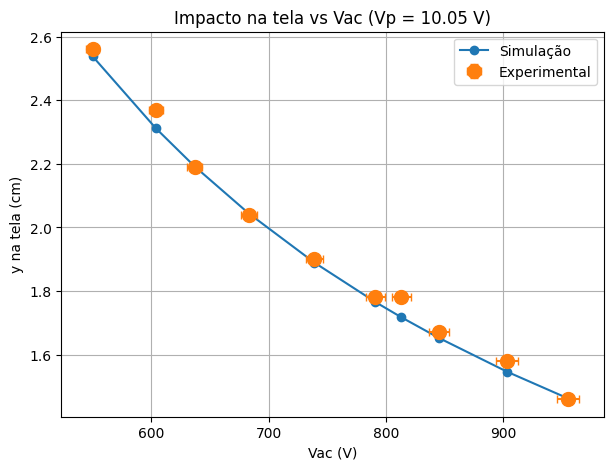


Intervalo da simulação:
y mínimo = 1.462 cm
y máximo = 2.538 cm


In [ ]:
# @title TESTE, em desenvolvimento
# ==========================================================
# BLOCO: Impacto na tela — Simulação vs Experimento
# ----------------------------------------------------------
# Autor: [Seu Nome]
# Data: [DD/MM/AAAA]
# Versão: 0.1
#
# Objetivo:
# Comparar a posição de impacto na tela obtida por simulação
# com dados experimentais, incluindo incertezas.
#
# Entradas:
# - Vptraj: tensão de placa selecionada (Vp)
# - Vacfixo: vetor de tensões de aceleração
# - yVp: matriz de trajetórias simuladas
# - csv_exp: arquivo com dados experimentais
#
# Saídas:
# - Gráfico comparativo (simulação vs experimento)
# - Intervalo de valores simulados na tela
#
# Observações:
# - Executar após a simulação completa da trajetória
# - Se não houver dados experimentais, plota apenas simulação
# ==========================================================

# ================= CONFIGURAÇÕES =================
# Vptraj = 10.0                 # valor de Vp usado pelo aluno
# csv_exp = "teste femm/dados_tela.csv"   # arquivo experimental (opcional)
tamanho_ponto = 50

# ================= ÍNDICE DO Vp =================
idx_vp = np.argmin(np.abs(Vp - Vptraj))

# ================= EXTRAÇÃO DO PONTO NA TELA =================
# último ponto da trajetória em x
y_tela_sim = yVp[:, idx_vp] * 100  # converter m → cm

# ================= PLOT =================
plt.figure(figsize=(7,5))

# -------- SIMULAÇÃO --------
plt.plot(
    Vacfixo,
    y_tela_sim,
    '-o',
    label='Simulação'
)

# ================= DADOS EXPERIMENTAIS =================
print("\nTentando carregar dados experimentais (formato esperado: Vac, y, sVac, sy)...")

try:
    df_exp = pd.read_csv(csv_exp_Vp_fixo)

    # -------- VALIDAÇÃO --------
    colunas = ["Vac", "y", "sVac", "sy"]
    for c in colunas:
        if c not in df_exp.columns:
            raise ValueError(f"Coluna '{c}' não encontrada")

    # -------- EXTRAÇÃO --------
    Vac_exp = df_exp["Vac"].values
    y_exp = df_exp["y"].values
    sVac = df_exp["sVac"].values
    sy = df_exp["sy"].values

    print("✔ Dados experimentais carregados.")

    # -------- PLOT EXPERIMENTAL --------
    plt.errorbar(
        Vac_exp, y_exp,
        xerr=sVac, yerr=sy,
        fmt='o',
        markersize=tamanho_ponto/5,
        capsize=3,
        label='Experimental'
    )

except Exception as e:
    print("\n⚠️ Dados experimentais não disponíveis.")
    print("→ Apenas a simulação será exibida.")
    print("→ Detalhe:", e)

# ================= FORMATAÇÃO =================
plt.title(f"Impacto na tela vs Vac (Vp = {Vptraj:.2f} V)")
plt.xlabel("Vac (V)")
plt.ylabel("y na tela (cm)")
plt.grid()
plt.legend()

plt.show()

# ================= INFORMAÇÃO ADICIONAL =================
print("\nIntervalo da simulação:")
print(f"y mínimo = {np.min(y_tela_sim):.3f} cm")
print(f"y máximo = {np.max(y_tela_sim):.3f} cm")